In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_classification
from sklearn.metrics import accuracy_score

In [12]:
# Utility functions
def one_hot_encode(y, num_classes):
    y = y.astype(int)
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

def softmax(logits):
    """
    logist: shape (n_samples, n_classes)
    numerically stable softmax
    """
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_vals = np.exp(shifted)
    return exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

def cross_entropy_loss(y_true_onehot, y_pred_proba):
    """average cross-entropy"""
    eps = 1e-12
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred_proba), axis=1))

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [13]:
# Softmax Regression from scratch
class SoftmaxRegressionScratch:
    def __init__(
        self,
        lr=0/1,
        n_iters=1000,
        fit_intercept=True,
        random_state=None
    ):
        self.lr = lr
        self.n_iters = n_iters
        self.fit_intercept = fit_intercept
        self.random_state = random_state

        self.W = None
        self.b = None
        self.classes_ = None
        self.loss_history = []

    def _initialise_params(self, n_features, n_classes):
        rng = np.random.default_rng(self.random_state)
        self.W = rng.normal(loc=0.0, scale=1.0, size=(n_features, n_classes))
        self.b = np.zeros((1, n_classes))

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        # map labels to 0,1,...,K-1 if necessary
        class_to_index = {c: i for i, c in enumerate(self.classes_)}
        y_index = np.array([class_to_index[val] for val in y])

        Y = one_hot_encode(y_index, n_classes)
        self._initialise_params(n_features, n_classes)

        for _ in range(self.n_iters):
            logits = X @ self.W + self.b
            probs = softmax(logits)

            loss = cross_entropy_loss(Y, probs)
            self.loss_history.append(loss)

            # gradients
            dlogits = (probs - Y) / n_samples
            dW = X.T @ dlogits
            db = np.sum(dlogits, axis=0, keepdims=True)

            # update
            self.W -= self.lr * dW
            self.b -= self.lr * db

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        logits = X @ self.W + self.b
        return softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        y_index_pred = np.argmax(probs, axis=1)
        return self.classes_[y_index_pred]

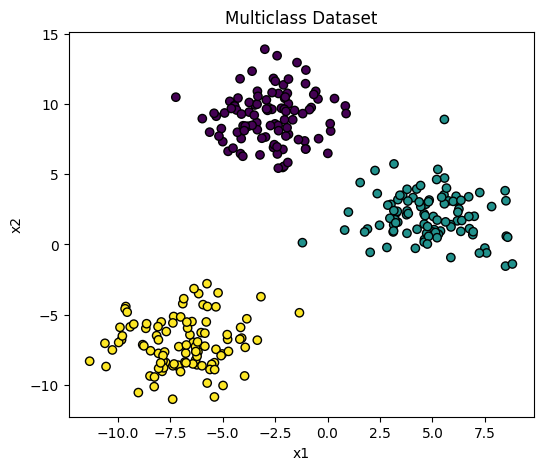

In [14]:
# Multiclass Dataset
X_multi, y_multi = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.8,
    random_state=42
)

plt.figure(figsize=(6, 5))
plt.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, cmap='viridis', edgecolor='k')
plt.title("Multiclass Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [17]:
# Train softmax regression
softmax_scratch = SoftmaxRegressionScratch(lr=0.1, n_iters=2000, random_state=42)
softmax_scratch.fit(X_multi, y_multi)

y_pred_scratch = softmax_scratch.predict(X_multi)
print("Scratch training accuracy:", accuracy(y_multi, y_pred_scratch).round(2))

Scratch training accuracy: 1.0


In [18]:
# Compare with sklearn
from sklearn.linear_model import LogisticRegression

softmax_sklearn = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)
softmax_sklearn.fit(X_multi, y_multi)

y_pred_sklearn = softmax_sklearn.predict(X_multi)
print("sklearn training accuracy:", accuracy_score(y_multi, y_pred_sklearn))

sklearn training accuracy: 1.0


/Users/kennyyu/miniconda3/envs/fmat3888/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


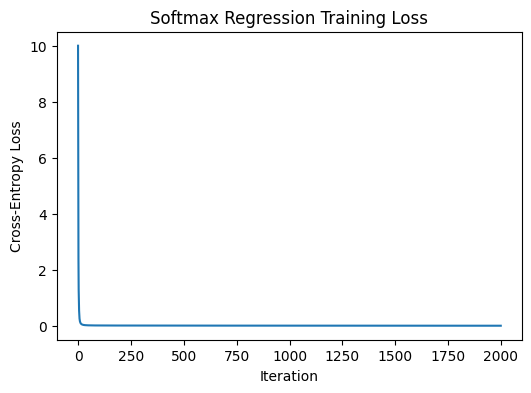

In [19]:
# Plot loss curve
plt.figure(figsize=(6, 4))
plt.plot(softmax_scratch.loss_history)
plt.title("Softmax Regression Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Cross-Entropy Loss")
plt.show()

In [20]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

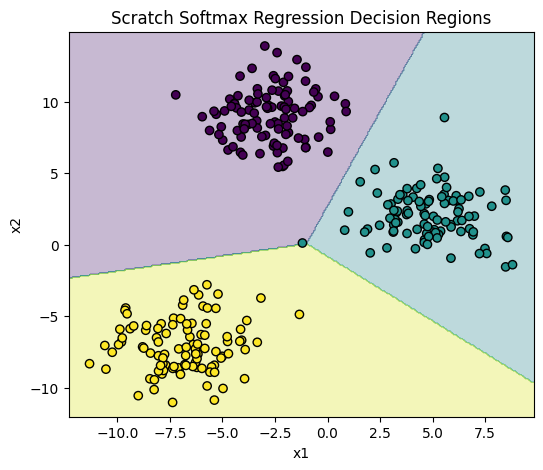

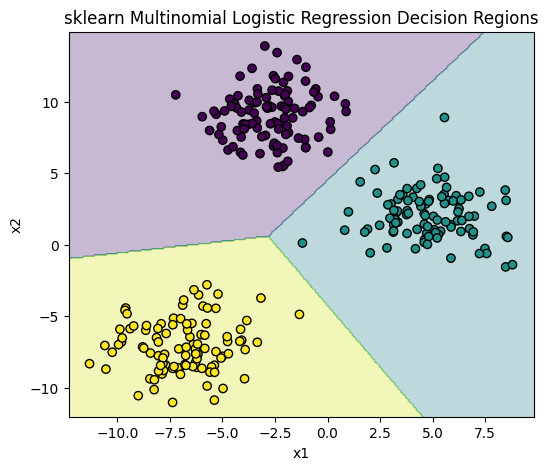

In [21]:
plot_decision_boundary(
    softmax_scratch,
    X_multi,
    y_multi,
    "Scratch Softmax Regression Decision Regions"
)

plot_decision_boundary(
    softmax_sklearn,
    X_multi,
    y_multi,
    "sklearn Multinomial Logistic Regression Decision Regions"
)

In [22]:
def plot_class_probability_surface(model, X, y, class_idx=0, title="Class Probability Surface"):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, class_idx].reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    contour = plt.contourf(xx, yy, probs, levels=30, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
    plt.colorbar(contour, label=f"P(class={class_idx})")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

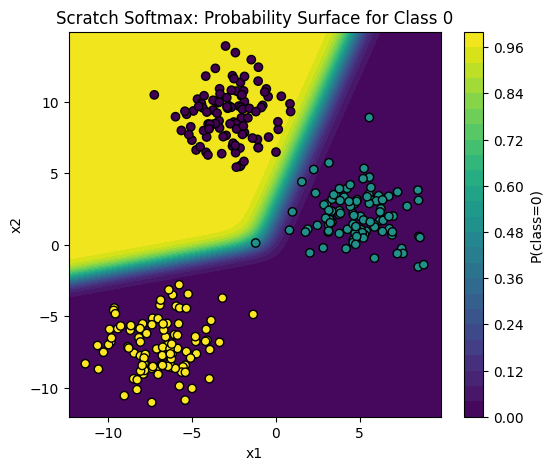

In [23]:
plot_class_probability_surface(
    softmax_scratch,
    X_multi,
    y_multi,
    class_idx=0,
    title="Scratch Softmax: Probability Surface for Class 0"
)

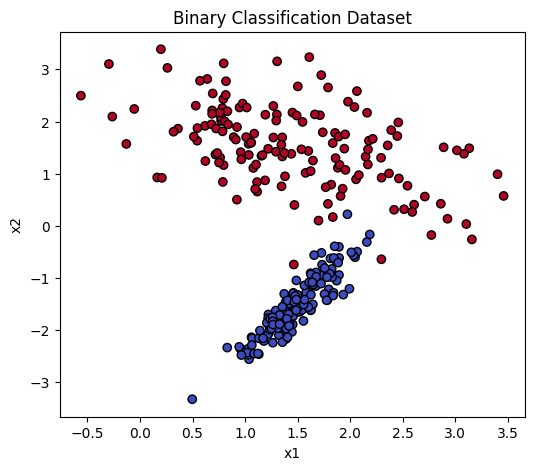

In [24]:
# Binary case: Logistic regression
# Binary dataset
X_bin, y_bin = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

plt.figure(figsize=(6, 5))
plt.scatter(X_bin[:, 0], X_bin[:, 1], c=y_bin, cmap='coolwarm', edgecolor='k')
plt.title("Binary Classification Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [28]:
# Train Softmax on Binary Dataset
logreg_scratch = SoftmaxRegressionScratch(
    lr=0.1,
    n_iters=2000,
    random_state=42
)
logreg_scratch.fit(X_bin, y_bin)

y_bin_pred_logistic = logreg_scratch.predict(X_bin)
print(f"Logistic scratch accuracy: {accuracy(y_bin, y_bin_pred_logistic)}")

Logistic scratch accuracy: 0.9866666666666667


In [29]:
# Train sklearn logistic regression
logreg_sklearn = LogisticRegression(max_iter=2000)
logreg_sklearn.fit(X_bin, y_bin)
y_bin_pred_sklearn = logreg_sklearn.predict(X_bin)
print(f"Logistic sklearn accuracy: {accuracy(y_bin, y_bin_pred_sklearn)}")

Logistic sklearn accuracy: 0.9866666666666667


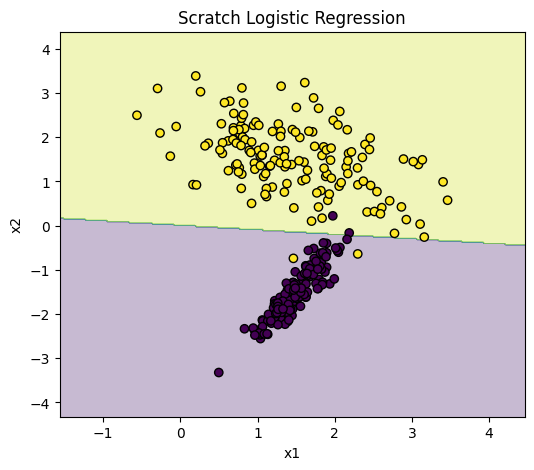

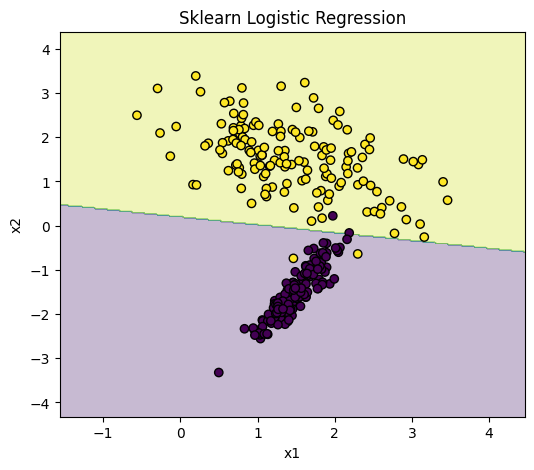

In [30]:
plot_decision_boundary(
    logreg_scratch,
    X_bin,
    y_bin,
    "Scratch Logistic Regression"
)

plot_decision_boundary(
    logreg_sklearn,
    X_bin,
    y_bin,
    "Sklearn Logistic Regression"
)

In [31]:
# Verify probability equivalence in binary case
probs_bin = logreg_scratch.predict_proba(X_bin[:5])
print("First 5 softmax probabilities:")
print(probs_bin)
print("Row sums:")
print(np.sum(probs_bin, axis=1))

First 5 softmax probabilities:
[[9.99884367e-01 1.15632921e-04]
 [7.00956723e-04 9.99299043e-01]
 [9.99995409e-01 4.59063319e-06]
 [4.85291605e-02 9.51470839e-01]
 [3.46657744e-04 9.99653342e-01]]
Row sums:
[1. 1. 1. 1. 1.]
